Images: 118
Neurons: 39209
Animate fraction: 0.5338983050847458
Explained variance PC1 (ViT): 0.17425905
Neural PCA shape: (118, 118)

--- Fisher Geometry (Population) ---
Trace(F): 869.4792130031584
Det(F):   1.689894401777437e+88
Effective dimension: 84.42282389123811


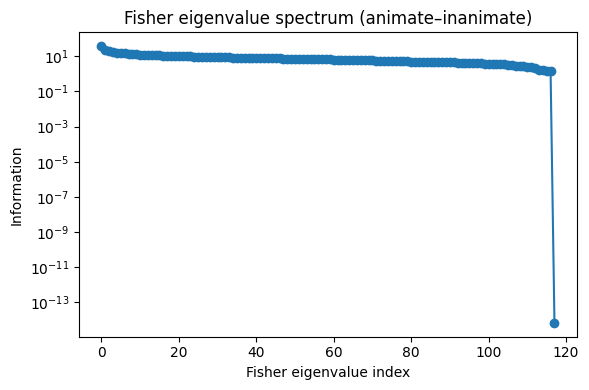

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("Images:", vit.shape[0])
print("Neurons:", R.shape[1])

# ============================================================
# ANIMATE / INANIMATE LABEL
# ============================================================

# ImageNet top-1 class indices (assumed available)
# classes 0–397 = animate, 398–999 = inanimate
top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # shape (images,)

print("Animate fraction:", y.mean())

# ============================================================
# SEMANTIC AXIS FROM ViT LOGITS (PC1)
# ============================================================

vit_z = StandardScaler().fit_transform(vit)

pca_vit = PCA(n_components=3)
vit_pca = pca_vit.fit_transform(vit_z)

semantic_axis = vit_pca[:, 0]

print("Explained variance PC1 (ViT):",
      pca_vit.explained_variance_ratio_[0])

# ============================================================
# NEURAL POPULATION COORDINATES
# ============================================================

Rz = StandardScaler().fit_transform(R)

N_PCA = 118
pca_R = PCA(n_components=N_PCA)
Z = pca_R.fit_transform(Rz)     # (images, N_PCA)

print("Neural PCA shape:", Z.shape)

# ============================================================
# LOGISTIC DECODER: POPULATION → ANIMACY
# ============================================================

clf = LogisticRegression(max_iter=2000)
clf.fit(Z, y)

p = clf.predict_proba(Z)[:, 1]   # P(animate | population)
W = p * (1 - p)                  # Bernoulli Fisher weights

# ============================================================
# FISHER INFORMATION MATRIX
# ============================================================

F = (Z.T * W) @ Z                # (N_PCA, N_PCA)

trace_F = np.trace(F)
det_F   = np.linalg.det(F + 1e-6 * np.eye(N_PCA))

# effective Fisher dimensionality
d_eff = (trace_F ** 2) / np.trace(F @ F)

print("\n--- Fisher Geometry (Population) ---")
print("Trace(F):", trace_F)
print("Det(F):  ", det_F)
print("Effective dimension:", d_eff)

# ============================================================
# FISHER EIGENSPECTRUM
# ============================================================

eigvals = np.linalg.eigvalsh(F)

plt.figure(figsize=(6,4))
plt.semilogy(eigvals[::-1], 'o-')
plt.xlabel("Fisher eigenvalue index")
plt.ylabel("Information")
plt.title("Fisher eigenvalue spectrum (animate–inanimate)")
plt.tight_layout()
plt.show()


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=0)

F_list = []
acc_list = []
ll_list = []

for tr, te in skf.split(Z, y):
    clf = LogisticRegression(max_iter=4000)
    clf.fit(Z[tr], y[tr])

    p = clf.predict_proba(Z[te])[:, 1]
    W = p * (1 - p)

    F_te = (Z[te].T * W) @ Z[te]
    F_list.append(F_te)

    acc_list.append(np.mean((p > 0.5) == y[te]))
    # log loss:
    eps = 1e-12
    ll_list.append(np.mean(y[te]*np.log(p+eps) + (1-y[te])*np.log(1-p+eps)))

F_cv = sum(F_list) / len(F_list)

eigvals_cv = np.linalg.eigvalsh(F_cv)
trace_cv = np.trace(F_cv)
d_eff_cv = (trace_cv**2) / np.trace(F_cv @ F_cv)

print("CV accuracy:", np.mean(acc_list))
print("CV mean log-lik:", np.mean(ll_list))
print("CV Trace(F):", trace_cv)
print("CV d_eff:", d_eff_cv)


CV accuracy: 0.6447368421052632
CV mean log-lik: -0.9806925073661116
CV Trace(F): 74029.2673440429
CV d_eff: 50.973740437814904



=== CV Fisher Geometry (whitened) ===
CV Accuracy: 0.6609649122807018
CV Log-likelihood: -0.6510549045393687
Trace(F): 193.00552374197324
Effective dimension: 46.989150090419706
Shuffle d_eff mean ± std: 47.114350062345345 0.7429270164972362


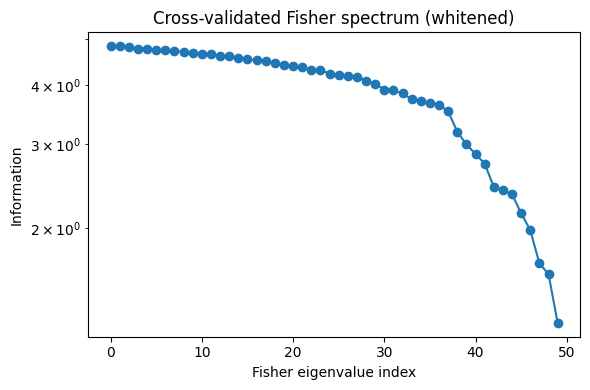

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']
R   = np.load(NEURAL_PATH).T

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

# ============================================================
# STANDARDIZE + WHITEN NEURAL DATA
# ============================================================

Rz = StandardScaler().fit_transform(R)
N_PCA = 50

pca = PCA(n_components=N_PCA, whiten=True)
Z = pca.fit_transform(Rz)

# ============================================================
# CROSS-VALIDATED FISHER
# ============================================================

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=0)

def fisher_from_probs(Z, p):
    W = p * (1 - p)
    return (Z.T * W) @ Z

F_sum = np.zeros((N_PCA, N_PCA))
accs, lls = [], []

for tr, te in skf.split(Z, y):
    clf = LogisticRegression(max_iter=4000, C=0.1)
    clf.fit(Z[tr], y[tr])

    p = clf.predict_proba(Z[te])[:, 1]
    F_sum += fisher_from_probs(Z[te], p)

    accs.append(np.mean((p > 0.5) == y[te]))
    lls.append(np.mean(y[te]*np.log(p+1e-9)+(1-y[te])*np.log(1-p+1e-9)))

F = F_sum / skf.get_n_splits()

eigvals = np.linalg.eigvalsh(F)[::-1]
traceF = np.trace(F)
d_eff = (traceF**2) / np.trace(F @ F)

print("\n=== CV Fisher Geometry (whitened) ===")
print("CV Accuracy:", np.mean(accs))
print("CV Log-likelihood:", np.mean(lls))
print("Trace(F):", traceF)
print("Effective dimension:", d_eff)

# ============================================================
# SHUFFLE NULL
# ============================================================

d_null = []
for _ in range(200):
    y_shuf = np.random.permutation(y)
    F_s = np.zeros((N_PCA, N_PCA))

    for tr, te in skf.split(Z, y_shuf):
        clf = LogisticRegression(max_iter=4000, C=0.1)
        clf.fit(Z[tr], y_shuf[tr])
        p = clf.predict_proba(Z[te])[:, 1]
        F_s += fisher_from_probs(Z[te], p)

    F_s /= skf.get_n_splits()
    trF = np.trace(F_s)
    d_null.append((trF**2) / np.trace(F_s @ F_s))

print("Shuffle d_eff mean ± std:", np.mean(d_null), np.std(d_null))

# ============================================================
# EIGENSPECTRUM PLOT
# ============================================================

plt.figure(figsize=(6,4))
plt.semilogy(eigvals, 'o-')
plt.xlabel("Fisher eigenvalue index")
plt.ylabel("Information")
plt.title("Cross-validated Fisher spectrum (whitened)")
plt.tight_layout()
plt.show()



=== Empirical Fisher (true labels) ===
CV Accuracy: 0.5600877192982455
CV Log-likelihood: -0.7002289805356292
Trace(F): 274.50083018521536
Effective dimension: 33.47751437328199
Shuffle d_eff mean ± std: 34.832461087070854 1.7813203958672488


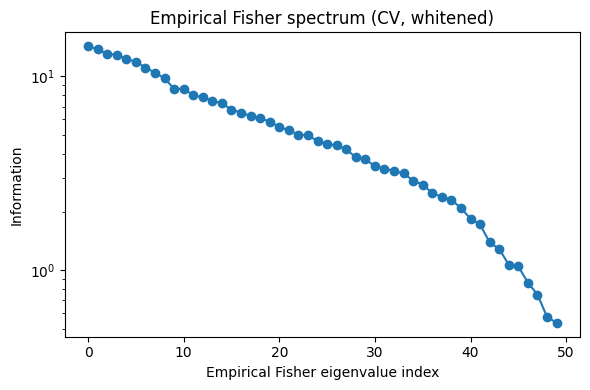

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']
R   = np.load(NEURAL_PATH).T

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

# ============================================================
# STANDARDIZE + WHITEN NEURAL DATA
# ============================================================

Rz = StandardScaler().fit_transform(R)
N_PCA = 50

pca = PCA(n_components=N_PCA, whiten=True)
Z = pca.fit_transform(Rz)

# ============================================================
# EMPIRICAL GRADIENT FISHER
# ============================================================

def empirical_fisher(Z, y, p):
    G = ((y - p)[:, None]) * Z
    return G.T @ G

# ============================================================
# CROSS-VALIDATION
# ============================================================

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=0)

F_sum = np.zeros((N_PCA, N_PCA))
accs, lls = [], []

for tr, te in skf.split(Z, y):
    clf = LogisticRegression(max_iter=4000, C=0.1)
    clf.fit(Z[tr], y[tr])

    p = clf.predict_proba(Z[te])[:, 1]
    F_sum += empirical_fisher(Z[te], y[te], p)

    accs.append(np.mean((p > 0.5) == y[te]))
    lls.append(np.mean(y[te]*np.log(p+1e-9)+(1-y[te])*np.log(1-p+1e-9)))

F = F_sum / skf.get_n_splits()

eigvals = np.linalg.eigvalsh(F)[::-1]
traceF = np.trace(F)
d_eff = (traceF**2) / np.trace(F @ F)

print("\n=== Empirical Fisher (true labels) ===")
print("CV Accuracy:", np.mean(accs))
print("CV Log-likelihood:", np.mean(lls))
print("Trace(F):", traceF)
print("Effective dimension:", d_eff)

# ============================================================
# SHUFFLE NULL
# ============================================================

d_null = []
for _ in range(200):
    y_shuf = np.random.permutation(y)
    F_s = np.zeros((N_PCA, N_PCA))

    for tr, te in skf.split(Z, y_shuf):
        clf = LogisticRegression(max_iter=4000, C=0.1)
        clf.fit(Z[tr], y_shuf[tr])
        p = clf.predict_proba(Z[te])[:, 1]
        F_s += empirical_fisher(Z[te], y_shuf[te], p)

    F_s /= skf.get_n_splits()
    trF = np.trace(F_s)
    d_null.append((trF**2) / np.trace(F_s @ F_s))

print("Shuffle d_eff mean ± std:", np.mean(d_null), np.std(d_null))

# ============================================================
# EIGENSPECTRUM
# ============================================================

plt.figure(figsize=(6,4))
plt.semilogy(eigvals, 'o-')
plt.xlabel("Empirical Fisher eigenvalue index")
plt.ylabel("Information")
plt.title("Empirical Fisher spectrum (CV, whitened)")
plt.tight_layout()
plt.show()


Images kept: 78
Neurons: 39209
Animate fraction: 0.5

=== Neuron-space empirical Fisher (diagonal) ===
CV accuracy: 0.6923076923076924
CV log-likelihood: -0.565902234337975


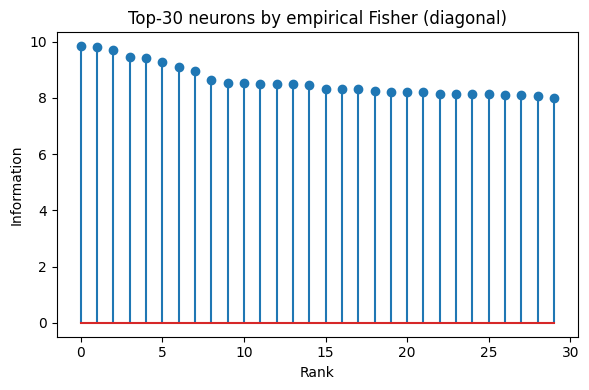

In [ ]:
#https://chatgpt.com/g/g-p-676c80353b988191819d6d02aca806d6/project

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']
R   = np.load(NEURAL_PATH).T

# ============================================================
# ANIMACY SCORE (log-sum-exp margin)
# ============================================================

A = np.arange(0, 398)
I = np.arange(398, 1000)

def logsumexp(x):
    m = x.max(axis=1, keepdims=True)
    return m.squeeze() + np.log(np.sum(np.exp(x - m), axis=1))

s_anim = logsumexp(vit[:, A]) - logsumexp(vit[:, I])

q1, q2 = np.quantile(s_anim, [0.33, 0.67])
mask = (s_anim < q1) | (s_anim > q2)

y = (s_anim[mask] > 0).astype(int)
X = R[mask]

print("Images kept:", X.shape[0])
print("Neurons:", X.shape[1])
print("Animate fraction:", y.mean())

# ============================================================
# STANDARDIZE NEURONS
# ============================================================

Xz = StandardScaler().fit_transform(X)

# ============================================================
# STREAMING EMPIRICAL FISHER DIAGONAL
# ============================================================

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=0)

F_diag = np.zeros(Xz.shape[1])
accs, lls = [], []

for tr, te in skf.split(Xz, y):
    clf = LogisticRegression(
        penalty="l2",
        C=0.03,
        solver="saga",
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(Xz[tr], y[tr])

    p = clf.predict_proba(Xz[te])[:, 1]

    accs.append(np.mean((p > 0.5) == y[te]))
    lls.append(np.mean(y[te]*np.log(p+1e-9)+(1-y[te])*np.log(1-p+1e-9)))

    # accumulate diagonal only
    r = (y[te] - p)**2   # shape (n_samples,)
    F_diag += np.sum((Xz[te]**2) * r[:, None], axis=0)

F_diag /= skf.get_n_splits()

print("\n=== Neuron-space empirical Fisher (diagonal) ===")
print("CV accuracy:", np.mean(accs))
print("CV log-likelihood:", np.mean(lls))

# ============================================================
# TOP NEURONS
# ============================================================

idx = np.argsort(F_diag)[-30:][::-1]

plt.figure(figsize=(6,4))
plt.stem(F_diag[idx])
plt.title("Top-30 neurons by empirical Fisher (diagonal)")
plt.xlabel("Rank")
plt.ylabel("Information")
plt.tight_layout()
plt.show()


Images kept: 78
Neurons: 39209
Animate fraction: 0.5

=== Decoder performance ===
CV accuracy: 0.6923076923076924
CV log-likelihood: -0.5656654272698287


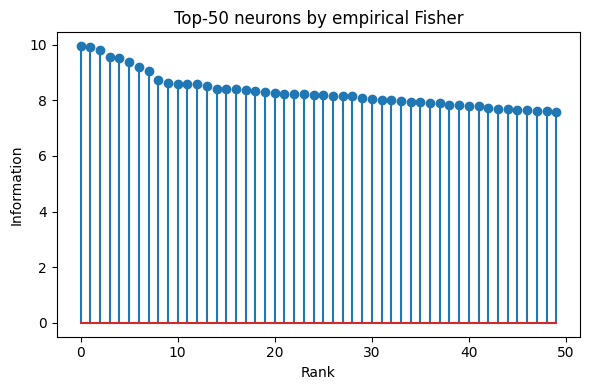

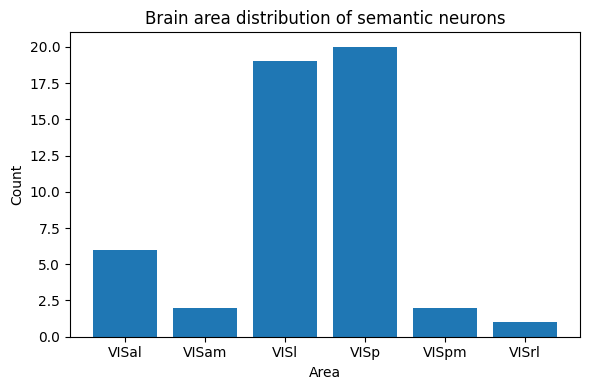

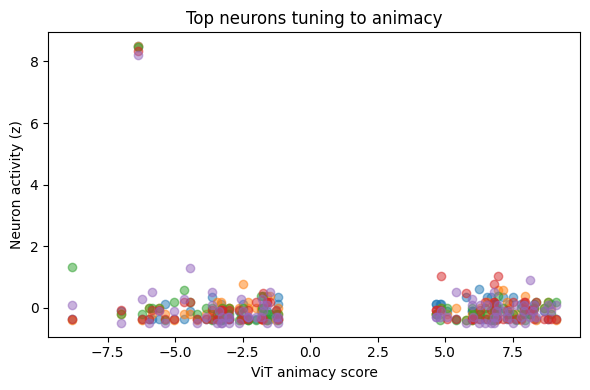

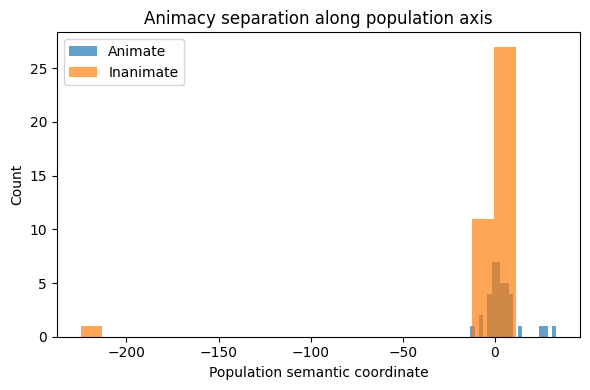

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

# ============================================================
# ANIMACY SEMANTIC SCORE (log-sum-exp margin)
# ============================================================

A = np.arange(0, 398)
I = np.arange(398, 1000)

def logsumexp(x):
    m = x.max(axis=1, keepdims=True)
    return m.squeeze() + np.log(np.sum(np.exp(x - m), axis=1))

s_anim = logsumexp(vit[:, A]) - logsumexp(vit[:, I])

# keep confident extremes
q1, q2 = np.quantile(s_anim, [0.33, 0.67])
mask = (s_anim < q1) | (s_anim > q2)

y = (s_anim[mask] > 0).astype(int)
X = R[mask]
areas = areas

print("Images kept:", X.shape[0])
print("Neurons:", X.shape[1])
print("Animate fraction:", y.mean())

# ============================================================
# STANDARDIZE NEURON RESPONSES
# ============================================================

Xz = StandardScaler().fit_transform(X)

# ============================================================
# EMPIRICAL FISHER (DIAGONAL ONLY)
# ============================================================

def empirical_fisher_diag(X, y, p):
    r = (y - p) ** 2
    return np.sum((X ** 2) * r[:, None], axis=0)

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=0)

F_diag = np.zeros(Xz.shape[1])
accs, lls = [], []

for tr, te in skf.split(Xz, y):
    clf = LogisticRegression(
        penalty="l2",
        C=0.03,
        solver="saga",
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(Xz[tr], y[tr])

    p = clf.predict_proba(Xz[te])[:, 1]

    accs.append(np.mean((p > 0.5) == y[te]))
    lls.append(np.mean(y[te]*np.log(p+1e-9)+(1-y[te])*np.log(1-p+1e-9)))

    F_diag += empirical_fisher_diag(Xz[te], y[te], p)

F_diag /= skf.get_n_splits()

print("\n=== Decoder performance ===")
print("CV accuracy:", np.mean(accs))
print("CV log-likelihood:", np.mean(lls))

# ============================================================
# TOP SEMANTIC NEURONS
# ============================================================

K = 50
top_idx = np.argsort(F_diag)[-K:][::-1]

plt.figure(figsize=(6,4))
plt.stem(F_diag[top_idx])
plt.title(f"Top-{K} neurons by empirical Fisher")
plt.xlabel("Rank")
plt.ylabel("Information")
plt.tight_layout()
plt.show()

# ============================================================
# AREA DISTRIBUTION
# ============================================================

unique, counts = np.unique(areas[top_idx], return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique, counts)
plt.title("Brain area distribution of semantic neurons")
plt.xlabel("Area")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ============================================================
# NEURON TUNING CURVES
# ============================================================

plt.figure(figsize=(6,4))
for j in top_idx[:5]:
    plt.plot(s_anim[mask], Xz[:, j], 'o', alpha=0.5)
plt.xlabel("ViT animacy score")
plt.ylabel("Neuron activity (z)")
plt.title("Top neurons tuning to animacy")
plt.tight_layout()
plt.show()

# ============================================================
# POPULATION SEMANTIC AXIS
# ============================================================

w = np.zeros(Xz.shape[1])
w[top_idx] = np.sign(np.mean(Xz[y==1][:, top_idx], axis=0)
                     - np.mean(Xz[y==0][:, top_idx], axis=0))

pop_axis = Xz @ w

plt.figure(figsize=(6,4))
plt.hist(pop_axis[y==1], bins=20, alpha=0.7, label="Animate")
plt.hist(pop_axis[y==0], bins=20, alpha=0.7, label="Inanimate")
plt.legend()
plt.xlabel("Population semantic coordinate")
plt.ylabel("Count")
plt.title("Animacy separation along population axis")
plt.tight_layout()
plt.show()
